# 05 — Ladder summary (Phase D-3)

All 11 rungs side-by-side: cumsum P&L plot, Sharpe / DD / t-stat table, F3 ladder
decomposition with winsor variants, and per-year Sharpe stability for the
headline `rung_6w` (the resume-bullet candidate).

**Pass criterion for D-3:** rung_6w gross Sharpe positive in ≥ 8 of 14 years
(2010–2023) → strategy is regime-stable, not a single-year fluke.


In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import config, eval as evalmod


In [2]:
# 11 rungs in the comparison ladder (all completed in the Track A sweep)
RUNG_IDS = [
    'rung_1_simple_momentum_decile',  'rung_1d_simple_momentum_dual',
    'rung_2_ewm_momentum_decile',     'rung_2d_ewm_momentum_dual',
    'rung_3_ts_regression_decile',    'rung_3d_ts_regression_dual',
    'rung_4_linear_tcnn',
    'rung_5_tcnn_1ch',                'rung_5w_tcnn_1ch_winsor',
    'rung_6_tcnn_3ch',                'rung_6w_tcnn_3ch_winsor',
]
HEADLINE = 'rung_6w_tcnn_3ch_winsor'

master = evalmod.load_master_results(RUNG_IDS)
master['date'] = pd.to_datetime(master['date'])
master['year'] = master['date'].dt.year
print(f'{len(master):,} daily-return records across {master["experiment_id"].nunique()} rungs')
print(f'year range: {master.year.min()} – {master.year.max()}')


48,540 daily-return records across 11 rungs
year range: 2010 – 2023


## Sharpe / max-DD table (the headline)


In [3]:
summary = (master.groupby('experiment_id')['return']
                  .apply(lambda s: pd.Series(evalmod.perf_summary(s)))
                  .unstack())
summary = summary[['ann_return', 'ann_vol', 'sharpe', 'max_dd', 't_stat', 'n_days']]
summary.loc[RUNG_IDS].round(3)  # ordered by rung


,ann_return,ann_vol,sharpe,max_dd,t_stat,n_days
experiment_id,,,,,,
rung_1_simple_momentum_decile,0.030,0.116,0.317,-0.214,1.108,3086.0
rung_1d_simple_momentum_dual,0.010,0.268,0.167,-0.707,0.585,3086.0
rung_2_ewm_momentum_decile,0.031,0.106,0.343,-0.174,1.201,3086.0
rung_2d_ewm_momentum_dual,-0.206,0.324,-0.551,-0.979,-1.927,3086.0
rung_3_ts_regression_decile,-0.007,0.065,-0.083,-0.191,-0.289,3086.0
rung_3d_ts_regression_dual,-0.038,0.224,-0.065,-0.661,-0.227,3086.0
rung_4_linear_tcnn,-0.030,0.489,0.188,-0.986,1.533,16680.0
rung_5_tcnn_1ch,0.025,0.251,0.224,-0.603,0.815,3336.0
rung_5w_tcnn_1ch_winsor,0.040,0.096,0.459,-0.257,1.669,3336.0


## Cumulative P&L plot (cumsum)


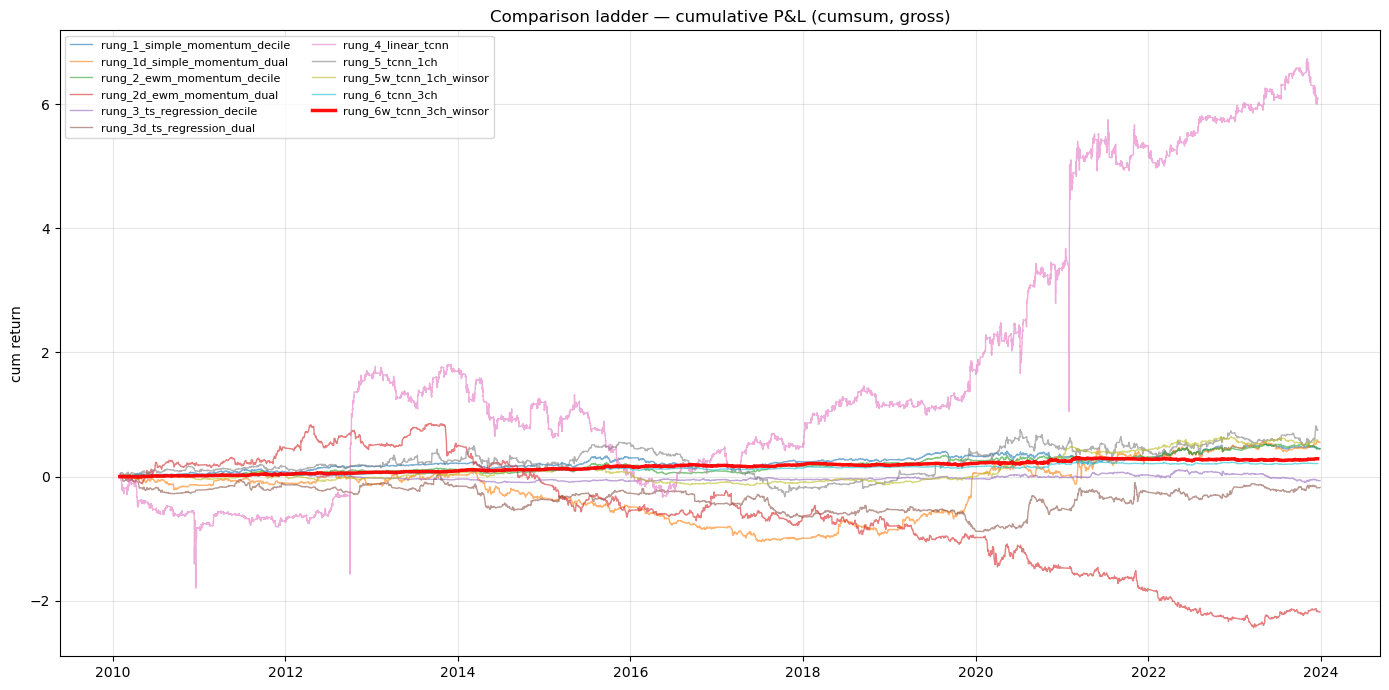

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))
for exp_id in RUNG_IDS:
    df = master[master['experiment_id'] == exp_id].sort_values('date')
    is_headline = (exp_id == HEADLINE)
    ax.plot(df['date'], df['return'].cumsum(),
            label=exp_id, alpha=0.95 if is_headline else 0.60,
            linewidth=2.5 if is_headline else 1.0,
            color='red' if is_headline else None)
ax.set(title='Comparison ladder — cumulative P&L (cumsum, gross)', ylabel='cum return')
ax.legend(loc='upper left', fontsize=8, ncol=2); ax.grid(alpha=0.3); plt.tight_layout()


## Decomposition: F3 ladder (with winsor variants) — what each step adds

Compares the F3 thesis (learnable aggregation) across rungs holding the input
constant (past returns at lags 1..252). The winsor variants (5w, 6w) isolate
the contribution of the portfolio-mapping fix.


In [5]:
# Three "ladders" to read distinct stories:
#   F3:   1 -> 2 -> 4 -> 5     (each step adds a capability, same portfolio map = decile/dual)
#   F2:   5 -> 5w  AND  6 -> 6w   (portfolio map fix, same architecture)
#   Channels:  5 -> 6  AND  5w -> 6w (1ch -> 3ch input, same architecture)

ladders = {
    'F3 (function class)': ['rung_1_simple_momentum_decile',
                             'rung_2_ewm_momentum_decile',
                             'rung_4_linear_tcnn',
                             'rung_5_tcnn_1ch'],
    'F2 (winsor)':          ['rung_5_tcnn_1ch', 'rung_5w_tcnn_1ch_winsor',
                             'rung_6_tcnn_3ch', 'rung_6w_tcnn_3ch_winsor'],
    'Channels (1ch->3ch)':  ['rung_5_tcnn_1ch', 'rung_6_tcnn_3ch',
                             'rung_5w_tcnn_1ch_winsor', 'rung_6w_tcnn_3ch_winsor'],
}
for name, rungs in ladders.items():
    print(f'\n=== {name} ===')
    sub = summary.loc[rungs, ['sharpe']].copy()
    sub['delta_sharpe'] = sub['sharpe'].diff()
    print(sub.round(3).to_string())



=== F3 (function class) ===
                               sharpe  delta_sharpe
experiment_id                                      
rung_1_simple_momentum_decile   0.317           NaN
rung_2_ewm_momentum_decile      0.343         0.026
rung_4_linear_tcnn              0.188        -0.155
rung_5_tcnn_1ch                 0.224         0.036

=== F2 (winsor) ===
                         sharpe  delta_sharpe
experiment_id                                
rung_5_tcnn_1ch           0.224           NaN
rung_5w_tcnn_1ch_winsor   0.459         0.235
rung_6_tcnn_3ch           0.441        -0.018
rung_6w_tcnn_3ch_winsor   0.662         0.221

=== Channels (1ch->3ch) ===
                         sharpe  delta_sharpe
experiment_id                                
rung_5_tcnn_1ch           0.224           NaN
rung_6_tcnn_3ch           0.441         0.217
rung_5w_tcnn_1ch_winsor   0.459         0.018
rung_6w_tcnn_3ch_winsor   0.662         0.203


## Per-year Sharpe — regime stability of the headline

Same gross Sharpe formula, but bucketed by calendar year. For the headline
candidate `rung_6w_tcnn_3ch_winsor` we want positive Sharpe in **≥ 8 of 14**
years to claim the strategy is regime-stable rather than concentrated in a
lucky window (e.g. COVID 2020).


In [6]:
def yearly_sharpe_table(master_df, rungs):
    rows = []
    for exp_id in rungs:
        sub = master_df[master_df['experiment_id'] == exp_id]
        for yr, grp in sub.groupby('year'):
            r = grp['return']
            sr = r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan
            rows.append({'rung': exp_id, 'year': int(yr), 'sharpe': sr, 'n_days': len(r)})
    return (pd.DataFrame(rows)
              .pivot(index='year', columns='rung', values='sharpe')
              .reindex(columns=rungs)
              .round(3))

HEADLINE_RUNGS = ['rung_5_tcnn_1ch', 'rung_5w_tcnn_1ch_winsor',
                  'rung_6_tcnn_3ch', 'rung_6w_tcnn_3ch_winsor']
yearly = yearly_sharpe_table(master, HEADLINE_RUNGS)
print(yearly.to_string())


rung  rung_5_tcnn_1ch  rung_5w_tcnn_1ch_winsor  rung_6_tcnn_3ch  rung_6w_tcnn_3ch_winsor
year                                                                                    
2010            0.716                   -0.621            0.387                    0.632
2011            0.645                    0.733            0.466                    0.771
2012            0.083                   -0.651            0.746                    1.362
2013            0.373                    1.469            1.837                    1.388
2014           -0.461                    0.533            0.801                    1.108
2015            1.733                   -0.307            1.097                    2.113
2016           -2.320                   -2.577           -0.709                    0.286
2017           -1.560                    0.328            1.347                    0.743
2018            0.516                   -0.477            0.529                   -0.415
2019            1.663


rung_6w_tcnn_3ch_winsor:  12 of 14 years positive  (need >= 8 of 14)
D-3 PASS

per-year mean Sharpe: 0.762   std across years: 0.642
min: -0.415  (2018)
max: 2.113  (2015)


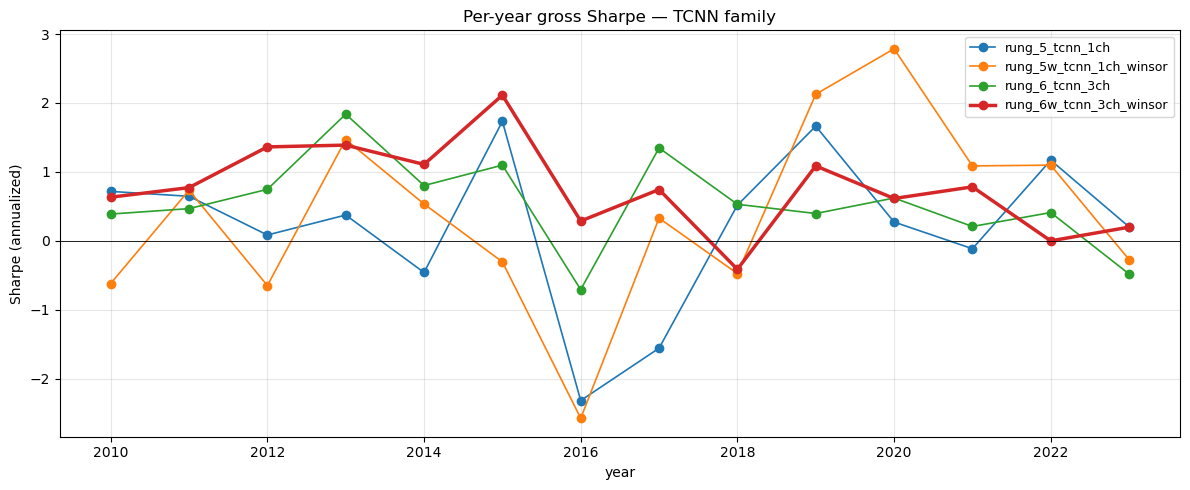

In [7]:
# Per-year visual + D-3 PASS/FAIL gate
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'rung_5_tcnn_1ch':'#1f77b4', 'rung_5w_tcnn_1ch_winsor':'#ff7f0e',
          'rung_6_tcnn_3ch':'#2ca02c', 'rung_6w_tcnn_3ch_winsor':'#d62728'}
for col in yearly.columns:
    ax.plot(yearly.index, yearly[col], marker='o', label=col,
            linewidth=2.5 if col == HEADLINE else 1.2, color=colors.get(col))
ax.axhline(0, color='k', linewidth=0.6); ax.grid(alpha=0.3)
ax.set(title='Per-year gross Sharpe — TCNN family', xlabel='year', ylabel='Sharpe (annualized)')
ax.legend(loc='best', fontsize=9); plt.tight_layout()

# D-3 gate
hl = yearly[HEADLINE]
pos_yrs = int((hl > 0).sum())
total_yrs = int(hl.notna().sum())
print(f'\n{HEADLINE}:  {pos_yrs} of {total_yrs} years positive  (need >= 8 of 14)')
print('D-3 PASS' if pos_yrs >= 8 else 'D-3 FAIL — regime-concentrated')
print(f'\nper-year mean Sharpe: {hl.mean():.3f}   std across years: {hl.std():.3f}')
print(f'min: {hl.min():.3f}  ({yearly.index[hl.argmin()]})')
print(f'max: {hl.max():.3f}  ({yearly.index[hl.argmax()]})')
